In [ ]:
!pip install torch

# Hyundai Cars — ANN Maintenance Prediction with ClearML

Trains a small **Artificial Neural Network (ANN)** on two separate tasks:

| Task | Target | Type |
|------|--------|------|
| **Model A** | `maintenance_type` | Multi-class (3 classes) |
| **Model B** | `anomaly_indication` | Binary |

Features, EDA, preprocessing, ClearML tracking, and artifact saving are shared across both tasks.

In [1]:
from pathlib import Path
import os, pickle, copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from clearml import Logger, Task
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score,
    classification_report, f1_score,
    precision_score, recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42
TEST_SIZE    = 0.2
EPOCHS       = 60
BATCH_SIZE   = 64
LR           = 1e-3
PATIENCE     = 10          # early-stopping patience
CLEARML_PROJECT = "605-Vehicle_Maintainance-project"

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [2]:
data_path = Path("..") / "data" / "cars_hyundai.csv"
print(f"Dataset path: {data_path.resolve()}")

df_raw = pd.read_csv(data_path)
print(f"Raw shape: {df_raw.shape}")
df_raw.head()

Dataset path: D:\MSML\SEM 2\605 Computing systems for ML\Vehicle-Maintenance-Prediction-MLOps\data\cars_hyundai.csv
Raw shape: (1100, 5)


,Engine Temperature (°C),Brake Pad Thickness (mm),Tire Pressure (PSI),Maintenance Type,Anomaly Indication
0,81.022390,7.984018,35.964546,Repair,0
1,98.076029,10.718692,32.143593,Routine Maintenance,1
2,81.205967,10.983070,31.058628,Routine Maintenance,1
3,86.081294,7.045311,28.539264,Repair,0
4,93.496568,9.948991,33.599560,Component Replacement,1


In [3]:
print("Raw columns:", df_raw.columns.tolist())

def fuzzy_rename(columns):
    mapping = {}
    for col in columns:
        lc = col.lower().strip()
        if "engine" in lc and "temp" in lc:
            mapping[col] = "engine_temperature_c"
        elif "brake" in lc and "pad" in lc:
            mapping[col] = "brake_pad_thickness_mm"
        elif "tire" in lc or "tyre" in lc:
            mapping[col] = "tire_pressure_psi"
        elif "maintenance" in lc and "type" in lc:
            mapping[col] = "maintenance_type"
        elif "anomaly" in lc:
            mapping[col] = "anomaly_indication"
    return mapping

rename_map = fuzzy_rename(df_raw.columns)
print("Rename map:", rename_map)

df = df_raw.rename(columns=rename_map).drop_duplicates().reset_index(drop=True)

ALL_FEATURE_COLS = ["engine_temperature_c", "brake_pad_thickness_mm", "tire_pressure_psi"]

missing = [c for c in ALL_FEATURE_COLS + ["maintenance_type", "anomaly_indication"]
           if c not in df.columns]
if missing:
    raise ValueError(f"Missing after rename: {missing}\nActual: {df.columns.tolist()}")

print("\nFinal columns:", df.columns.tolist())
df.head()

Raw columns: ['Engine Temperature (°C)', 'Brake Pad Thickness (mm)', 'Tire Pressure (PSI)', 'Maintenance Type', 'Anomaly Indication']
Rename map: {'Engine Temperature (°C)': 'engine_temperature_c', 'Brake Pad Thickness (mm)': 'brake_pad_thickness_mm', 'Tire Pressure (PSI)': 'tire_pressure_psi', 'Maintenance Type': 'maintenance_type', 'Anomaly Indication': 'anomaly_indication'}

Final columns: ['engine_temperature_c', 'brake_pad_thickness_mm', 'tire_pressure_psi', 'maintenance_type', 'anomaly_indication']


,engine_temperature_c,brake_pad_thickness_mm,tire_pressure_psi,maintenance_type,anomaly_indication
0,81.022390,7.984018,35.964546,Repair,0
1,98.076029,10.718692,32.143593,Routine Maintenance,1
2,81.205967,10.983070,31.058628,Routine Maintenance,1
3,86.081294,7.045311,28.539264,Repair,0
4,93.496568,9.948991,33.599560,Component Replacement,1


In [4]:
print("Missing values:")
display(df.isna().sum().to_frame("missing_count"))

print("\nmaintenance_type distribution:")
display(df["maintenance_type"].value_counts().to_frame("count"))

print("\nanomaly_indication distribution:")
display(df["anomaly_indication"].value_counts().to_frame("count"))

print("\nDescriptive stats (features):")
display(df[ALL_FEATURE_COLS].describe().T)

Missing values:


,missing_count
engine_temperature_c,0
brake_pad_thickness_mm,0
tire_pressure_psi,0
maintenance_type,0
anomaly_indication,0



maintenance_type distribution:


,count
maintenance_type,
Component Replacement,370
Repair,365
Routine Maintenance,365



anomaly_indication distribution:


,count
anomaly_indication,
1,551
0,549



Descriptive stats (features):


,count,mean,std,min,25%,50%,75%,max
engine_temperature_c,1100.0,90.108394,5.797819,80.025954,84.868469,90.461940,94.907044,99.980940
brake_pad_thickness_mm,1100.0,8.986553,1.737784,6.001549,7.418846,9.039794,10.423316,11.994006
tire_pressure_psi,1100.0,33.090653,2.876990,28.009132,30.670348,33.169252,35.625786,37.992710


C:\Users\upratham\AppData\Local\Temp\ipykernel_24780\1912728627.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="maintenance_type", palette="Set2",
C:\Users\upratham\AppData\Local\Temp\ipykernel_24780\1912728627.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="anomaly_indication", palette="Set1",


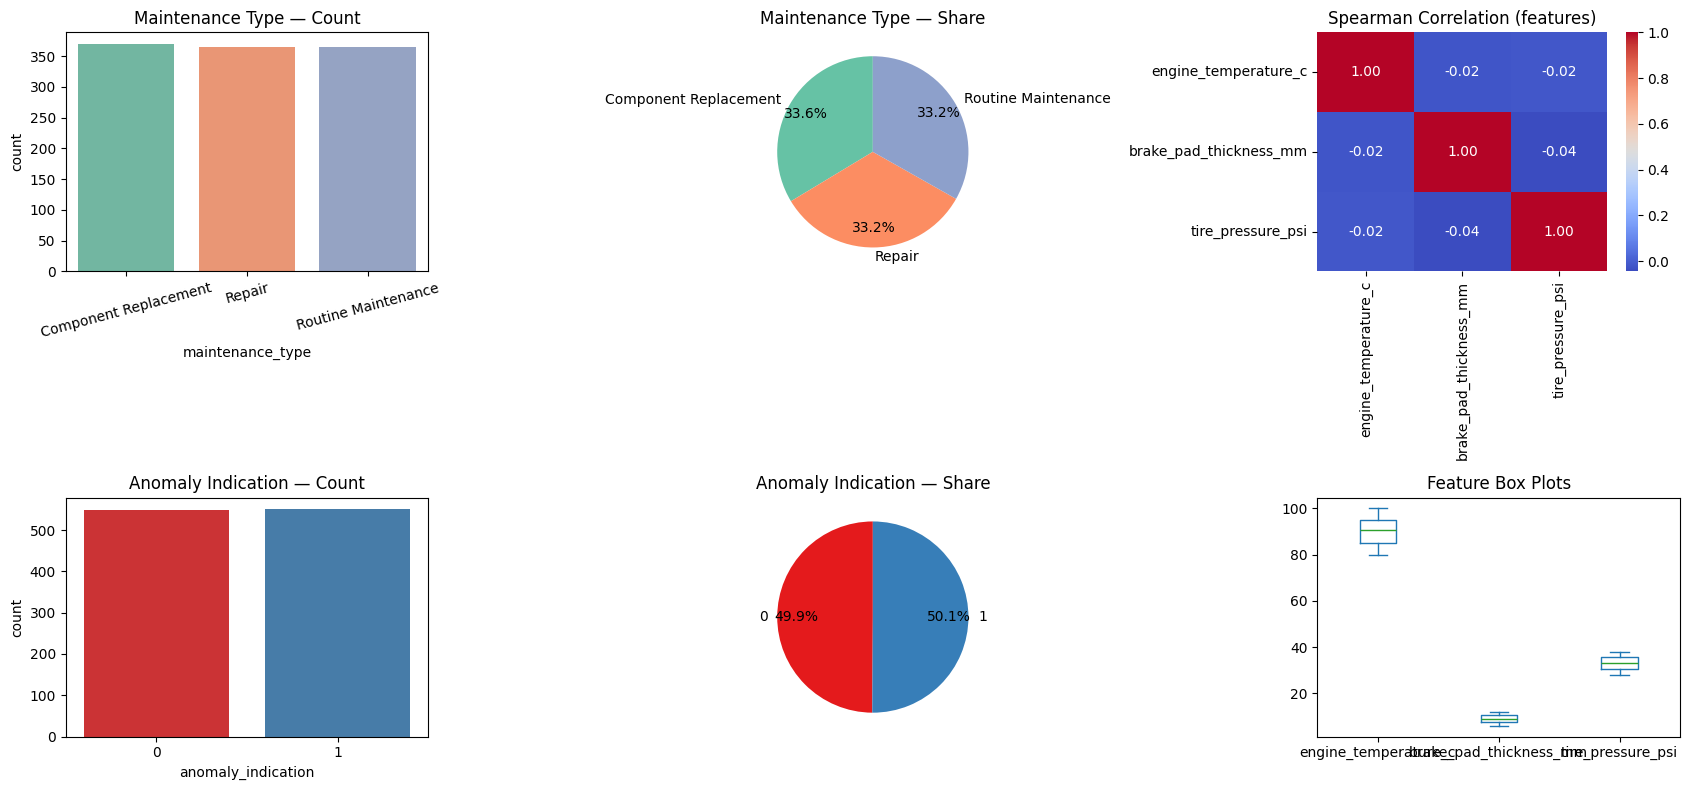

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8))

# ── Row 0: maintenance_type ───────────────────────────────────────────────────
mt_dist = df["maintenance_type"].value_counts().sort_index()
mt_classes = sorted(df["maintenance_type"].unique())
mt_dist = mt_dist.reindex(mt_classes, fill_value=0)

sns.countplot(data=df, x="maintenance_type", palette="Set2",
              order=mt_classes, ax=axes[0, 0])
axes[0, 0].set_title("Maintenance Type — Count")
axes[0, 0].tick_params(axis="x", rotation=15)

mt_dist.plot(kind="pie", autopct="%.1f%%", ax=axes[0, 1],
             labels=[str(c) for c in mt_dist.index],
             colors=sns.color_palette("Set2", n_colors=len(mt_dist)),
             pctdistance=0.80, startangle=90)
axes[0, 1].set_ylabel("")
axes[0, 1].set_title("Maintenance Type — Share")

# ── Row 0 col 2: correlation ──────────────────────────────────────────────────
corr = df[ALL_FEATURE_COLS].corr(method="spearman")
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[0, 2])
axes[0, 2].set_title("Spearman Correlation (features)")

# ── Row 1: anomaly_indication ─────────────────────────────────────────────────
ai_dist = df["anomaly_indication"].value_counts().sort_index()
ai_classes = sorted(df["anomaly_indication"].unique())
ai_dist = ai_dist.reindex(ai_classes, fill_value=0)

sns.countplot(data=df, x="anomaly_indication", palette="Set1",
              order=ai_classes, ax=axes[1, 0])
axes[1, 0].set_title("Anomaly Indication — Count")

ai_dist.plot(kind="pie", autopct="%.1f%%", ax=axes[1, 1],
             labels=[str(c) for c in ai_dist.index],
             colors=sns.color_palette("Set1", n_colors=len(ai_dist)),
             pctdistance=0.80, startangle=90)
axes[1, 1].set_ylabel("")
axes[1, 1].set_title("Anomaly Indication — Share")

# Feature distributions
df[ALL_FEATURE_COLS].plot(kind="box", ax=axes[1, 2])
axes[1, 2].set_title("Feature Box Plots")

plt.tight_layout()
plt.show()

In [ ]:
class SmallANN(nn.Module):
    """
    Small feed-forward ANN for classification.

    Architecture:
        Input(n_features)
          → Linear(64) → BatchNorm → ReLU → Dropout(0.3)
          → Linear(32) → BatchNorm → ReLU → Dropout(0.2)
          → Linear(n_classes)

    For binary tasks n_classes=1 (BCEWithLogitsLoss);
    for multi-class n_classes=K (CrossEntropyLoss).
    """
    def __init__(self, n_features: int, n_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, n_classes),
        )

    def forward(self, x):
        return self.net(x)


def make_loaders(X_tr, y_tr, X_te, y_te, batch_size, task="multiclass"):
    """Wrap numpy arrays in DataLoader. y dtype depends on task."""
    y_dtype = torch.float32 if task == "binary" else torch.long
    ds_train = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=y_dtype),
    )
    ds_test = TensorDataset(
        torch.tensor(X_te, dtype=torch.float32),
        torch.tensor(y_te, dtype=y_dtype),
    )
    return (DataLoader(ds_train, batch_size=batch_size, shuffle=True),
            DataLoader(ds_test,  batch_size=batch_size, shuffle=False))


def train_ann(model, train_loader, val_loader, epochs, lr, patience,
              task, logger, task_label):
    """
    Training loop with early stopping.
    Returns (trained_model, history_dict).
    """
    criterion = nn.BCEWithLogitsLoss() if task == "binary" else nn.CrossEntropyLoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode="min", patience=5, factor=0.5, 
    )

    best_val_loss = float("inf")
    best_weights  = copy.deepcopy(model.state_dict())
    no_improve    = 0
    history       = {"train_loss": [], "val_loss": [], "val_acc": []}

    model.to(DEVICE)

    for epoch in range(1, epochs + 1):
        # ── Train ────────────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad()
            out = model(Xb)
            if task == "binary":
                loss = criterion(out.squeeze(1), yb)
            else:
                loss = criterion(out, yb)
            loss.backward()
            optimiser.step()
            running_loss += loss.item() * len(Xb)
        train_loss = running_loss / len(train_loader.dataset)

        # ── Validate ─────────────────────────────────────────────────────────
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                out = model(Xb)
                if task == "binary":
                    loss = criterion(out.squeeze(1), yb)
                    preds = (torch.sigmoid(out.squeeze(1)) >= 0.5).long()
                    correct += (preds == yb.long()).sum().item()
                else:
                    loss = criterion(out, yb)
                    preds = out.argmax(dim=1)
                    correct += (preds == yb).sum().item()
                val_loss += loss.item() * len(Xb)
                total    += len(Xb)
        val_loss /= total
        val_acc   = correct / total

        scheduler.step(val_loss)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # ClearML scalar logging
        logger.report_scalar(f"{task_label}/loss", "train", train_loss, epoch)
        logger.report_scalar(f"{task_label}/loss", "val",   val_loss,   epoch)
        logger.report_scalar(f"{task_label}/acc",  "val",   val_acc,    epoch)

        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d}/{epochs}  "
                  f"train_loss={train_loss:.4f}  "
                  f"val_loss={val_loss:.4f}  "
                  f"val_acc={val_acc:.4f}")

        # ── Early stopping ────────────────────────────────────────────────────
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_weights  = copy.deepcopy(model.state_dict())
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stop at epoch {epoch}")
                break

    model.load_state_dict(best_weights)
    return model, history


def evaluate_ann(model, loader, task, class_names):
    """Returns (y_true, y_pred) numpy arrays."""
    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(DEVICE)
            out = model(Xb)
            if task == "binary":
                preds = (torch.sigmoid(out.squeeze(1)) >= 0.5).long().cpu().numpy()
            else:
                preds = out.argmax(dim=1).cpu().numpy()
            all_true.extend(yb.numpy().astype(int))
            all_pred.extend(preds)
    return np.array(all_true), np.array(all_pred)


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"],   label="Val Loss")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(history["val_acc"], color="green", label="Val Accuracy")
    axes[1].set_title(f"{title} — Val Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].legend()

    plt.tight_layout(); plt.show()

print("ANN class and helper functions defined.")

ANN class and helper functions defined.


In [7]:
if not os.getenv("CLEARML_API_ACCESS_KEY") and not os.getenv("CLEARML_OFFLINE_MODE"):
    os.environ["CLEARML_OFFLINE_MODE"] = "1"
    print("ClearML credentials not detected; running in offline mode.")

task = Task.init(
    project_name=CLEARML_PROJECT,
    task_name="cars_hyundai ANN — maintenance_type & anomaly_indication",
    task_type=Task.TaskTypes.training,
    reuse_last_task_id=False,
)
logger = Logger.current_logger()

task.connect({
    "epochs": EPOCHS, "batch_size": BATCH_SIZE, "lr": LR,
    "patience": PATIENCE, "test_size": TEST_SIZE, "random_state": RANDOM_STATE,
    "features": ALL_FEATURE_COLS,
})
print("ClearML task initialised.")

ClearML credentials not detected; running in offline mode.
ClearML Task: created new task id=4026998e7cd048dd9eadf745944cad9c
ClearML results page: https://app.clear.ml/projects/b2949c3425b24311929ad8b62c0e5f2f/experiments/4026998e7cd048dd9eadf745944cad9c/output/log
ClearML task initialised.


---
## Model A — `maintenance_type` (multi-class, 3 classes)

Features: `engine_temperature_c`, `brake_pad_thickness_mm`, `tire_pressure_psi`, **`anomaly_indication`**  
Target: `maintenance_type` (encoded to 0/1/2)

In [8]:
# ── Prepare data for Model A ──────────────────────────────────────────────────
FEAT_A   = ["engine_temperature_c", "brake_pad_thickness_mm",
            "tire_pressure_psi", "anomaly_indication"]
TARGET_A = "maintenance_type"

le_a = LabelEncoder()
y_a  = le_a.fit_transform(df[TARGET_A])
class_names_a = [str(c) for c in le_a.classes_]

scaler_a = RobustScaler()
X_a = scaler_a.fit_transform(df[FEAT_A].values)

X_tr_a, X_te_a, y_tr_a, y_te_a = train_test_split(
    X_a, y_a, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_a
)
print(f"Model A — train: {X_tr_a.shape}, test: {X_te_a.shape}")
print(f"Classes: {dict(enumerate(class_names_a))}")

train_loader_a, test_loader_a = make_loaders(
    X_tr_a, y_tr_a, X_te_a, y_te_a, BATCH_SIZE, task="multiclass"
)

Model A — train: (880, 4), test: (220, 4)
Classes: {0: 'Component Replacement', 1: 'Repair', 2: 'Routine Maintenance'}


In [9]:
# ── Train Model A ─────────────────────────────────────────────────────────────
print("Training Model A (maintenance_type)...")
model_a = SmallANN(n_features=len(FEAT_A), n_classes=len(class_names_a))
print(model_a)
print(f"Trainable params: {sum(p.numel() for p in model_a.parameters() if p.requires_grad):,}")

model_a, history_a = train_ann(
    model_a, train_loader_a, test_loader_a,
    epochs=EPOCHS, lr=LR, patience=PATIENCE,
    task="multiclass", logger=logger, task_label="modelA_mtype",
)
plot_history(history_a, "Model A — Maintenance Type")

Training Model A (maintenance_type)...
SmallANN(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=3, bias=True)
  )
)
Trainable params: 2,691


TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'

ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start


In [ ]:
# ── Evaluate Model A ──────────────────────────────────────────────────────────
y_true_a, y_pred_a = evaluate_ann(model_a, test_loader_a, "multiclass", class_names_a)

print("Model A — Classification Report (maintenance_type)")
print(classification_report(y_true_a, y_pred_a, target_names=class_names_a, zero_division=0))

metrics_a = {
    "test_accuracy":           float(accuracy_score(y_true_a, y_pred_a)),
    "test_f1_weighted":        float(f1_score(y_true_a, y_pred_a, average="weighted")),
    "test_precision_weighted": float(precision_score(y_true_a, y_pred_a, average="weighted", zero_division=0)),
    "test_recall_weighted":    float(recall_score(y_true_a, y_pred_a, average="weighted", zero_division=0)),
}
for k, v in metrics_a.items():
    logger.report_scalar(f"modelA_mtype/{k}", "ANN", v, 0)
    print(f"  {k}: {v:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_true_a, y_pred_a, display_labels=class_names_a, cmap="Blues", xticks_rotation=20
)
plt.title("Model A — Maintenance Type Confusion Matrix")
plt.tight_layout(); plt.show()

---
## Model B — `anomaly_indication` (binary)

Features: `engine_temperature_c`, `brake_pad_thickness_mm`, `tire_pressure_psi`  
Target: `anomaly_indication` (0 / 1)

In [ ]:
# ── Prepare data for Model B ──────────────────────────────────────────────────
FEAT_B   = ["engine_temperature_c", "brake_pad_thickness_mm", "tire_pressure_psi"]
TARGET_B = "anomaly_indication"

le_b = LabelEncoder()
y_b  = le_b.fit_transform(df[TARGET_B])
class_names_b = [str(c) for c in le_b.classes_]

scaler_b = RobustScaler()
X_b = scaler_b.fit_transform(df[FEAT_B].values)

X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_b, y_b.astype(np.float32),
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_b
)
print(f"Model B — train: {X_tr_b.shape}, test: {X_te_b.shape}")
print(f"Classes: {dict(enumerate(class_names_b))}")

train_loader_b, test_loader_b = make_loaders(
    X_tr_b, y_tr_b, X_te_b, y_te_b, BATCH_SIZE, task="binary"
)

In [ ]:
# ── Train Model B ─────────────────────────────────────────────────────────────
print("Training Model B (anomaly_indication)...")
model_b = SmallANN(n_features=len(FEAT_B), n_classes=1)
print(model_b)
print(f"Trainable params: {sum(p.numel() for p in model_b.parameters() if p.requires_grad):,}")

model_b, history_b = train_ann(
    model_b, train_loader_b, test_loader_b,
    epochs=EPOCHS, lr=LR, patience=PATIENCE,
    task="binary", logger=logger, task_label="modelB_anomaly",
)
plot_history(history_b, "Model B — Anomaly Indication")

In [ ]:
# ── Evaluate Model B ──────────────────────────────────────────────────────────
y_true_b, y_pred_b = evaluate_ann(model_b, test_loader_b, "binary", class_names_b)

print("Model B — Classification Report (anomaly_indication)")
print(classification_report(y_true_b, y_pred_b, target_names=class_names_b, zero_division=0))

metrics_b = {
    "test_accuracy":           float(accuracy_score(y_true_b, y_pred_b)),
    "test_f1_weighted":        float(f1_score(y_true_b, y_pred_b, average="weighted")),
    "test_precision_weighted": float(precision_score(y_true_b, y_pred_b, average="weighted", zero_division=0)),
    "test_recall_weighted":    float(recall_score(y_true_b, y_pred_b, average="weighted", zero_division=0)),
}
for k, v in metrics_b.items():
    logger.report_scalar(f"modelB_anomaly/{k}", "ANN", v, 0)
    print(f"  {k}: {v:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_true_b, y_pred_b, display_labels=class_names_b, cmap="Oranges", xticks_rotation=20
)
plt.title("Model B — Anomaly Indication Confusion Matrix")
plt.tight_layout(); plt.show()

---
## Summary Comparison

In [ ]:
summary = pd.DataFrame([
    {"task": "maintenance_type (A)",  "model": "ANN", **metrics_a},
    {"task": "anomaly_indication (B)", "model": "ANN", **metrics_b},
])
display(summary)
logger.report_table("hyundai_ann", "summary_comparison", iteration=0, table_plot=summary)

In [ ]:
artifact_dir = Path("..") / "artifact"
artifact_dir.mkdir(parents=True, exist_ok=True)

for tag, model, scaler, le, feat, metrics in [
    ("mtype",   model_a, scaler_a, le_a, FEAT_A, metrics_a),
    ("anomaly", model_b, scaler_b, le_b, FEAT_B, metrics_b),
]:
    path = artifact_dir / f"hyundai_ann_{tag}.pkl"
    bundle = {
        "model_state_dict": model.cpu().state_dict(),
        "model_class":      "SmallANN",
        "n_features":       len(feat),
        "n_classes":        (3 if tag == "mtype" else 1),
        "scaler":           scaler,
        "label_encoder":    le,
        "feature_columns":  feat,
        "metrics":          metrics,
    }
    with open(path, "wb") as f:
        pickle.dump(bundle, f)
    print(f"Saved: {path.resolve()}")
    task.upload_artifact(f"hyundai_ann_{tag}", artifact_object=str(path.resolve()))

task.close()
print("\nAll done.")

## Outcome

### ANN Architecture (shared)
```
Input(n_features)
  → Linear(64) → BatchNorm1d → ReLU → Dropout(0.3)
  → Linear(32) → BatchNorm1d → ReLU → Dropout(0.2)
  → Linear(n_classes)
```
- **Model A** — `n_features=4`, `n_classes=3`, loss: `CrossEntropyLoss`
- **Model B** — `n_features=3`, `n_classes=1`, loss: `BCEWithLogitsLoss`
- Optimiser: Adam + `ReduceLROnPlateau` scheduler + early stopping (patience=10)
- ClearML logs per-epoch train/val loss & accuracy for both models